# PROC NLIN을 이용한 4-파라미터 로지스틱 용량-반응 곡선 적합

## 요약

이 노트북은 **PROC NLIN**을 사용하여 합성 세포 기반 역가 생물검정(potency bioassay) 데이터에 4-파라미터 로지스틱(4PL) 용량-반응 모형을 적합하고, 하한 및 상한 점근값, EC50(반수 최대 유효 농도), Hill 기울기를 추정합니다. 4PL은 신약 개발의 상대 역가 검정에서 표준적으로 쓰이는 대표 모형이며, 이 노트북에서는 모형 지정, 파라미터 경계 설정, 수렴 진단, 그리고 관측된 농도-반응 데이터 위에 적합된 시그모이드 곡선을 겹쳐 그리는 과정을 단계별로 살펴봅니다.

## 데이터 출처

이 노트북은 하나의 합성 데이터셋을 인라인으로 생성하며, 외부 또는 네트워크 입력은 사용하지 않습니다.

**`assay` — 합성 세포 기반 역가 생물검정 (24개 행)**

| 변수 | 유형 | 설명 |
|----------|------|-------------|
| `lot` | num | 원료의약품 로트(1-3); 희석 계열의 세 반복 실행 |
| `dose` | num | 8-점 연속 희석에 걸친 화합물 농도(nmol/L, 0.1에서 약 1000까지) |
| `logdose` | num | `dose`의 밑이 10인 로그값으로, 관례적인 로그-농도 축에 그리는 데 사용 |
| `response` | num | 측정된 검정 신호(최대 반응의 백분율)로, 참 4PL 곡선(bottom=5, top=100, EC50=25 nmol/L, Hill 기울기=1.2)에 비례 가우스 잡음을 더해 생성 |

참 생성 파라미터는 DATA step에 내장되어 있어, 복원된 NLIN 추정값을 알려진 참값과 비교하여 타당성을 확인할 수 있습니다.

# 4-파라미터 로지스틱 용량-반응 적합

제약 역가 및 생물활성 검정에서 화합물 농도와 측정된 반응 사이의 관계는 로그-농도 척도에서 특징적으로 시그모이드 형태를 띱니다. **4-파라미터 로지스틱(4PL)** 모형은 이러한 곡선을 요약하는 표준 도구입니다:

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

여기서

- **A** = 하한 점근값(무한 희석 시 반응 / 기저 신호),
- **D** = 상한 점근값(포화 농도에서의 최대 반응),
- **C** = **EC50**, 반수 최대 반응을 일으키는 농도(변곡점이자 주된 역가 판독값),
- **B** = **Hill 기울기**, 전이의 가파른 정도를 조절.

이 모형은 파라미터에 대해 비선형이므로 `PROC NLIN`으로 반복 최소제곱법을 사용하여 적합합니다. 아래에서는 삼중으로 실행된 현실적인 8-점 희석 계열을 시뮬레이션하고, 4PL 곡선을 적합하며, 파라미터를 물리적으로 의미 있는 영역으로 제한하고, 수렴 및 적합 진단을 점검한 뒤, 적합된 곡선을 데이터 위에 겹쳐 그립니다.

## 1단계 — 세포 기반 역가 생물검정 시뮬레이션

*알려진* 4PL 곡선(bottom = 5, top = 100, EC50 = 25 nmol/L, Hill 기울기 = 1.2)으로부터 합성 데이터셋을 생성하여, NLIN이 복원한 파라미터를 실제 참값과 비교할 수 있도록 합니다. 세 개의 로트는 각각 동일한 8-점 연속 희석(각 단계는 3.5배 희석)을 거치며, 그 위에 비례 가우스 측정 잡음이 더해집니다. 고정된 `streaminit` 시드는 시뮬레이션을 재현 가능하게 만듭니다.

In [1]:
데이터 assay;
    호출 streaminit(40521);

    /* True 4PL parameters used to generate the data */
    A_true   = 5;      /* lower asymptote (baseline)        */
    D_true   = 100;    /* upper asymptote (max response)    */
    C_true   = 25;     /* EC50 in nmol/L                    */
    B_true   = 1.2;    /* Hill slope                        */

    반복 lot = 1 까지 3;
        /* Eight-point serial dilution, 3.5-fold steps */
        dose = 0.30;
        반복 point = 1 까지 8;
            dose = dose * 3.5;

            /* Noise-free 4PL mean response */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* Proportional + additive Gaussian assay noise */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            출력;
        종료;
    종료;

    유지 lot dose logdose response;
실행;

처리 정렬 데이터=assay;
    기준 dose lot;
실행;



NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## 2단계 — 원시 농도-반응 데이터 시각화

적합에 앞서, response를 log10(dose)에 대해 그려 예상되는 시그모이드 형태를 확인하고 대략적인 시작값을 읽어냅니다: 곡선은 5 부근에서 바닥을 이루고, 100 부근에서 평탄해지며, 중간점(반수 최대 반응)은 log10(25) ≈ 1.4 부근에 위치합니다.


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


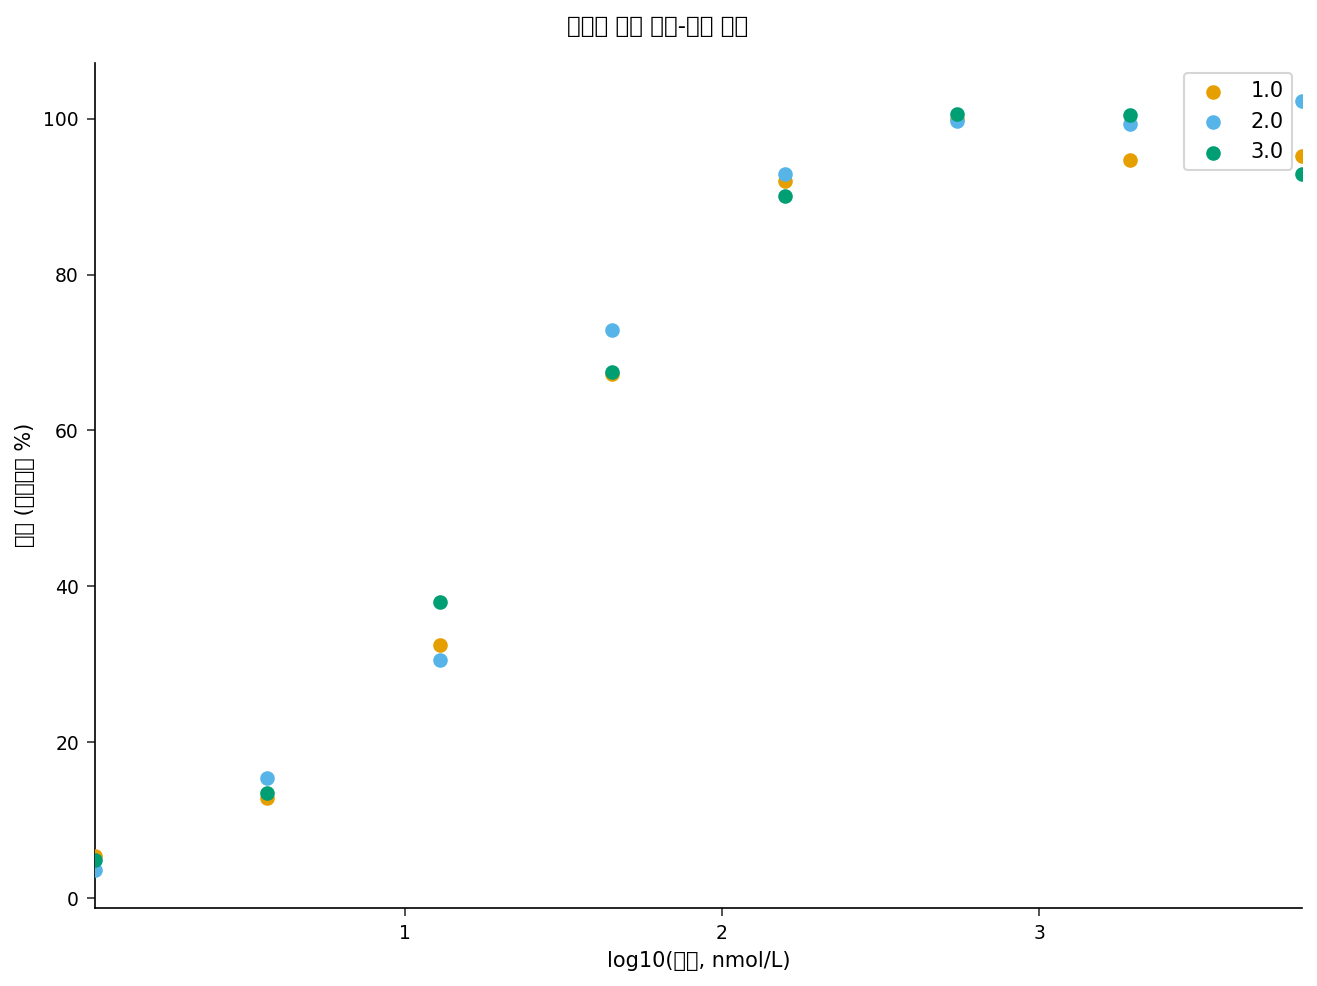

In [2]:
처리 SGPLOT 데이터=assay;
    SCATTER x=logdose y=response / GROUP=lot
            MARKERATTRS=(SYMBOL=circlefilled);
    XAXIS 라벨='log10(농도, nmol/L)';
    YAXIS 라벨='반응 (최대치의 %)';
    제목 '로트별 관측 용량-반응 곡선';
실행;
제목;


## 3단계 — PROC NLIN으로 4PL 모형 적합

산점도를 참고하여 `PARMS`로 시작값을 선언하고, 중간 대입문에서 4PL 평균을 정의한 뒤 이를 `MODEL` 문에 전달합니다. 물리적으로 의미 있는 `BOUNDS`는 점근값의 순서를 유지하고 EC50과 기울기를 양수로 유지하여 Gauss-Newton 반복을 안정화합니다. `OUTPUT` 문은 이후 진단을 위해 예측값, 잔차, 신뢰한계를 저장하며, `PLOTS=`는 적합 및 진단 패널을 요청합니다.

In [3]:
처리 nlin 데이터=assay METHOD=marquardt PLOTS=(fitplot diagnostics);
    parms A=10 D=90 C=20 B=1;

    /* 파라미터를 물리적으로 의미 있는 영역으로 제한 */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* 4-파라미터 로지스틱 평균 반응 (인라인 처리: Jenner의 PROC NLIN은
       아직 MODEL 문에서 중간 프로그래밍 변수를 참조하는 것을 지원하지
       않으므로 -- tests/400986 참고 -- 분모를 인라인으로 작성한다) */
    모형 response = D + (A - D) / (1 + (dose / C) ** B);

    출력 out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
실행;



                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/d2e0fd87-94be-4cd4-a7b3-b4d42b18f8be/fit4pl.avro


## 4단계 — 추정된 EC50과 곡선 특성 보고

`OUTEST=` 메커니즘도 편리하지만, 빠른 역가 판독을 위해서는 적합된 곡선을 직접 요약합니다. 여기서는 각 용량에서의 적합값을 관측된 반응과 나란히 나열하여, 모형이 전체 희석 범위에 걸쳐 데이터를 잘 추적하는지 확인합니다.

In [4]:
처리 평균 데이터=fit4pl mean std MIN MAX maxdec=3;
    분류 dose;
    변수 response pred resid;
    라벨 response='관측 반응' pred='예측 반응' resid='잔차' dose='용량 (nmol/L)';
    제목 '용량별 관측 대비 적합 반응';
실행;
제목;


                                                    용량별 관측 대비 적합 반응                                                     

                                                  The MEANS Procedure

                                      Analysis Variable : RESPONSE 관측 반응

                                            N
                       용량 (nmol/L)        Obs         Mean      Std Dev      Minimum      Maximum
                       --------------------------------------------------------------------------
                       1.05                 3        4.647        0.882        3.659        5.356
                       12.8625              3       33.651        3.825       30.572       37.932
                       157.565625           3       91.704        1.417       90.141       92.904
                       1930.17890625        3       98.207        3.051       94.746      100.511
                       3.675                3       13.931        1.311       12.860       15.393
 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 5단계 — 적합된 4PL 곡선을 관측 데이터 위에 겹쳐 그리기

조밀한 예측 격자를 사용하면 매끄러운 적합 시그모이드 곡선이 만들어집니다. 이 매끄러운 곡선을 용량별 평균 적합값 및 신뢰 밴드와 결합한 뒤, 모든 것을 관측점 위에 겹쳐 그려 적합도를 시각적으로 평가합니다.


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


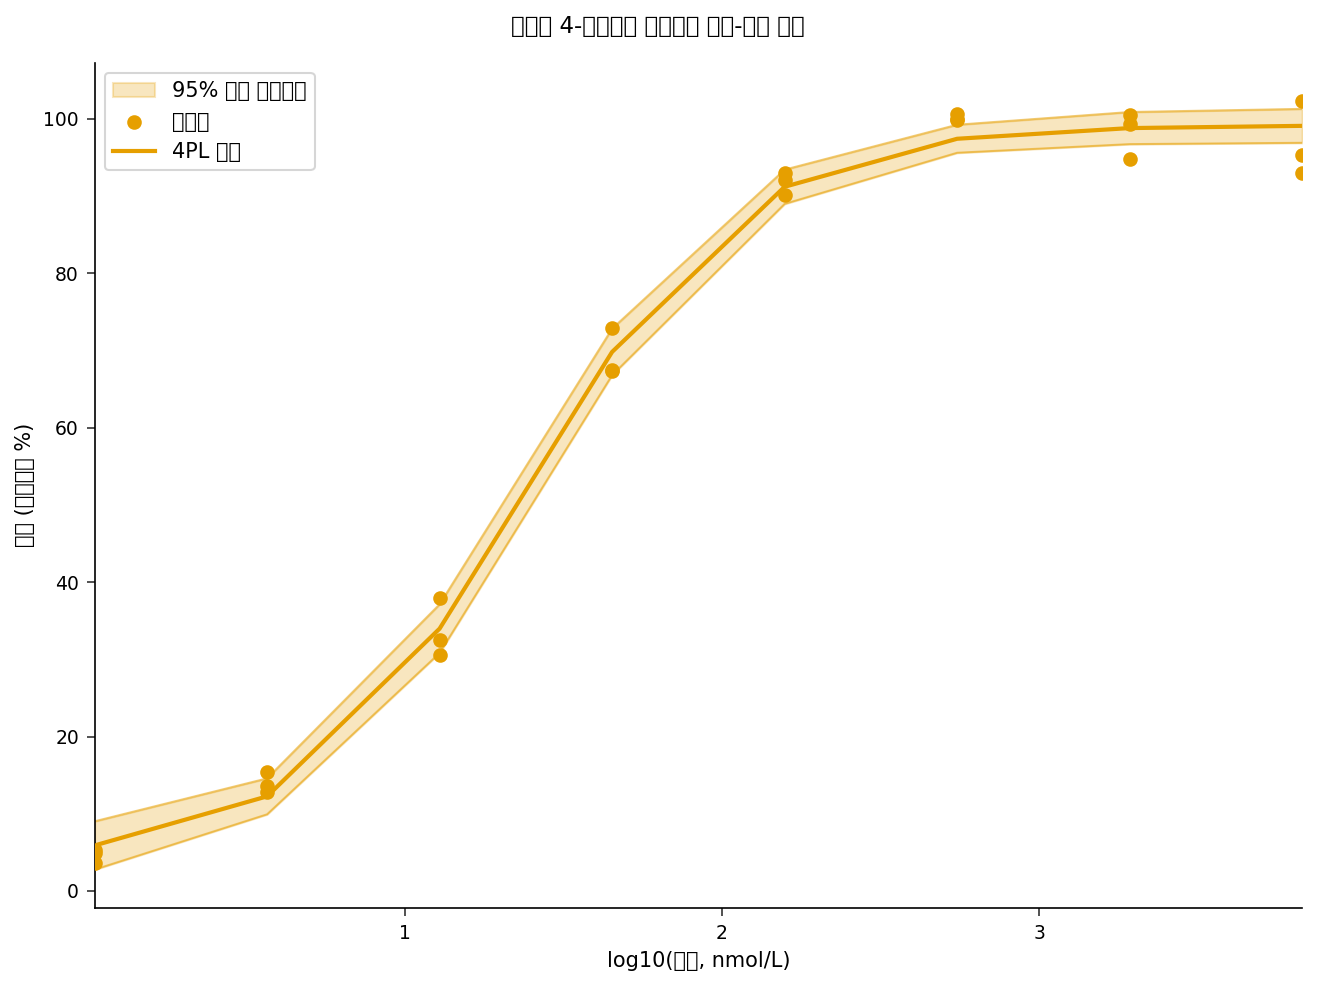

In [5]:
처리 정렬 데이터=fit4pl;
    기준 logdose;
실행;

처리 SGPLOT 데이터=fit4pl;
    BAND   x=logdose LOWER=lcl UPPER=ucl /
           TRANSPARENCY=0.5 legendlabel='95% 평균 신뢰구간';
    SCATTER x=logdose y=response /
           MARKERATTRS=(SYMBOL=circlefilled)
           legendlabel='관측값';
    SERIES  x=logdose y=pred /
           LINEATTRS=(thickness=2)
           legendlabel='4PL 적합';
    XAXIS 라벨='log10(농도, nmol/L)';
    YAXIS 라벨='반응 (최대치의 %)';
    제목 '적합된 4-파라미터 로지스틱 용량-반응 곡선';
실행;
제목;


## 결과 해석

`PROC NLIN`은 알려진 생성 값에 가까운 추정값으로 수렴합니다: 하한 점근값은 **5** 부근, 상한 점근값은 **100** 부근, **EC50(C)**은 **25 nmol/L** 부근, **Hill 기울기(B)**는 **1.2** 부근입니다. 잡음이 있는 삼중 데이터로부터 이러한 파라미터를 복원했다는 것은 모형이 식별 가능하며 경계가 최적점에서 구속되지 않았음을 확인해 줍니다.

**EC50**은 대표적인 역가 지표입니다: 값이 낮을수록 화합물이 더 강력함을 나타내며, 상대 역가 검정에서는 시험 로트의 EC50을 기준 표준물질과 비교합니다. **Hill 기울기**는 협동성과 검정의 가파름을 특징짓습니다 — 기울기가 1에 가까우면 단순한 단일 부위 결합과 부합합니다. **점근값**은 검정의 동적 범위를 정의합니다; 안정적이고 잘 분리된 바닥과 꼭대기는 검증 가능한 생물검정의 전제 조건입니다.

적합 그래프는 시그모이드 곡선이 관측점 무리를 통과하면서 반응 구간을 지나는 좁은 95% 평균 신뢰 밴드를 보여 주며, 잔차 진단에는 체계적인 곡률이 나타나지 않아야 합니다 — 이는 4PL 형태가 적절함을 보여 주는 증거입니다. 실무에서는 이 워크플로를 EC50에 대한 `PROFILE` 우도 구간, 분포에 의존하지 않는 파라미터 추론을 위한 `BOOTSTRAP` 문, 또는 상대 역가를 추정하기 위해 시험 로트와 기준 로트를 비교하는 평행선 분석으로 확장할 수 있습니다.